# Fluid Dynamics

Advect a velocity field and an image through a two-dimensional domain. Combine interpolation with an incompressibility projection, and inspect how these numerical ingredients create coherent fluid motion.


## Run this tour

Run the cells in order with a Python 3 kernel. The first cell locates the companion data and toolbox and installs missing dependencies when needed. All worked examples include their implementation directly in this notebook. Random seeds make comparisons reproducible; you can change them to explore other samples.


In [1]:
# Locate the companion toolbox locally, or fetch it for a standalone/Colab copy.
from pathlib import Path
import importlib.util
import os
import subprocess
import sys

working = Path.cwd()
candidates = [working, working / "python", working.parent / "python"]
python_dir = next((p for p in candidates if (p / "nt_toolbox").is_dir()), None)
if python_dir is None:
    checkout = working / "numerical-tours-support"
    if not checkout.exists():
        subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "--branch",
                "master",
                "https://github.com/gpeyre/numerical-tours.git",
                str(checkout),
            ],
            check=True,
        )
    python_dir = checkout / "python"
os.chdir(python_dir)
if str(python_dir) not in sys.path:
    sys.path.insert(0, str(python_dir))
requirements = python_dir / "requirements.txt"
if any(
    importlib.util.find_spec(name) is None
    for name in [
        "numpy",
        "scipy",
        "matplotlib",
        "skimage",
        "sklearn",
        "pywt",
        "ipywidgets",
        "cvxpy",
        "skfmm",
        "autograd",
        "progressbar",
        "celer",
    ]
):
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-r", str(requirements)], check=True
    )

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
plt.rcParams.update(
    {
        "figure.figsize": (8, 4),
        "figure.dpi": 100,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 11,
        "image.cmap": "gray",
    }
)
%matplotlib inline


$\newcommand{\dotp}[2]{\langle #1, #2 \rangle}$
$\newcommand{\enscond}[2]{\lbrace #1, #2 \rbrace}$
$\newcommand{\pd}[2]{ \frac{ \partial #1}{\partial #2} }$
$\newcommand{\umin}[1]{\underset{#1}{\min}\;}$
$\newcommand{\umax}[1]{\underset{#1}{\max}\;}$
$\newcommand{\uargmin}[1]{\underset{#1}{argmin}\;}$
$\newcommand{\norm}[1]{\|#1\|}$
$\newcommand{\abs}[1]{\left|#1\right|}$
$\newcommand{\choice}[1]{ \left\{  \begin{array}{l} #1 \end{array} \right. }$
$\newcommand{\pa}[1]{\left(#1\right)}$
$\newcommand{\diag}[1]{{diag}\left( #1 \right)}$
$\newcommand{\qandq}{\quad\text{and}\quad}$
$\newcommand{\qwhereq}{\quad\text{where}\quad}$
$\newcommand{\qifq}{ \quad \text{if} \quad }$
$\newcommand{\qarrq}{ \quad \Longrightarrow \quad }$
$\newcommand{\ZZ}{\mathbb{Z}}$
$\newcommand{\CC}{\mathbb{C}}$
$\newcommand{\RR}{\mathbb{R}}$
$\newcommand{\EE}{\mathbb{E}}$
$\newcommand{\Zz}{\mathcal{Z}}$
$\newcommand{\Ww}{\mathcal{W}}$
$\newcommand{\Vv}{\mathcal{V}}$
$\newcommand{\Nn}{\mathcal{N}}$
$\newcommand{\NN}{\mathcal{N}}$
$\newcommand{\Hh}{\mathcal{H}}$
$\newcommand{\Bb}{\mathcal{B}}$
$\newcommand{\Ee}{\mathcal{E}}$
$\newcommand{\Cc}{\mathcal{C}}$
$\newcommand{\Gg}{\mathcal{G}}$
$\newcommand{\Ss}{\mathcal{S}}$
$\newcommand{\Pp}{\mathcal{P}}$
$\newcommand{\Ff}{\mathcal{F}}$
$\newcommand{\Xx}{\mathcal{X}}$
$\newcommand{\Mm}{\mathcal{M}}$
$\newcommand{\Ii}{\mathcal{I}}$
$\newcommand{\Dd}{\mathcal{D}}$
$\newcommand{\Ll}{\mathcal{L}}$
$\newcommand{\Tt}{\mathcal{T}}$
$\newcommand{\si}{\sigma}$
$\newcommand{\al}{\alpha}$
$\newcommand{\la}{\lambda}$
$\newcommand{\ga}{\gamma}$
$\newcommand{\Ga}{\Gamma}$
$\newcommand{\La}{\Lambda}$
$\newcommand{\Si}{\Sigma}$
$\newcommand{\be}{\beta}$
$\newcommand{\de}{\delta}$
$\newcommand{\De}{\Delta}$
$\newcommand{\phi}{\varphi}$
$\newcommand{\th}{\theta}$
$\newcommand{\om}{\omega}$
$\newcommand{\Om}{\Omega}$


This numerical tour explores fluid dynamics for image generation.


In [2]:
import numpy as np
import scipy as scp
import pylab as pyl
import matplotlib.pyplot as plt

from nt_toolbox.general import np, plt, pylab
from nt_toolbox.signal import imageplot, load_image, np, plt, pylab

import warnings

%matplotlib inline

Velocity Flow Field
-------------------
A velocity flow is simply a 2-D vector field $V = (V_i)_{i=1}^N \in \RR^{n \times n \times 2}$
where $V_i \in \RR^2$ is one of the $N=n \times n$ vectors at a position indexed by $i$.


It can be generated as a realization of Gaussian process.
The blurring creates correlations in the flow.


In [3]:
n = 128  # grid size

In [4]:
t = np.linspace(0, 1, n)
[Y, X] = np.meshgrid(t, t)
gamma = 0.05  # blurring size
xi1 = np.exp(-((X - Y) ** 2) / gamma)
xi = lambda x: np.dot(np.dot(xi1, x), xi1)

In [5]:
from numpy import random

n = 128
V = np.random.randn(n, n, 2)
for k in range(2):
    V[:, :, k] = xi(V[:, :, k])

Subsampling display operator.


In [6]:
from nt_toolbox.plot_vf import np, plot_vf, plt, random

myplot = lambda V: plot_vf(
    V[np.ix_(np.arange(0, n, 6), np.arange(0, n, 6), np.arange(2))]
)

We can display the vector field using arrow.


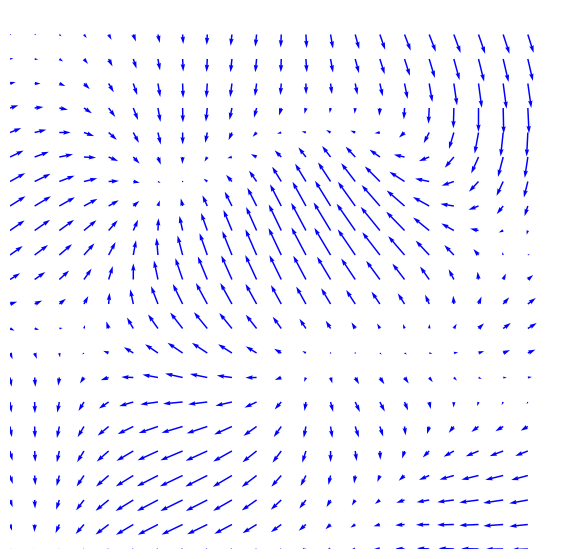

In [7]:
plt.figure(figsize=(7, 7))
myplot(V)

We can renormalize the flow, which enhances the singularities. It defines
$\tilde V$ as $\tilde V_i = V_i/\norm{V_i}$.


In [8]:
normalize = lambda V: (
    V
    / (
        np.repeat(
            np.maximum(1e-9 * np.ones(np.shape(V)[:2]), np.sqrt(np.sum(V**2, 2)))[
                :, :, np.newaxis
            ],
            2,
            axis=2,
        )
    )
)

Display.


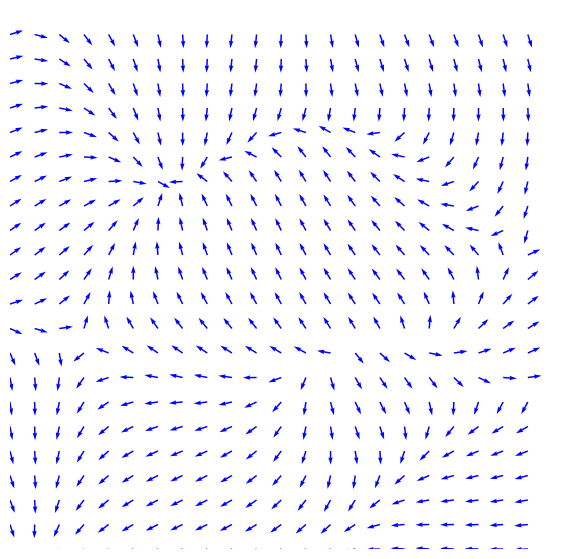

In [9]:
plt.figure(figsize=(7, 7))
myplot(normalize(V))

Incompressible Flows
--------------------
An incompressible flow has a vanishing divergence. The set of vector
incompressible flow defines a sub-space of $\RR^{n \times n \times 2}$
$$ \Ii = \enscond{V}{ \text{div}(V)=0 }
  \qwhereq \text{div}(V) = \pd{V}{x_1} + \pd{V}{x_2} \in \RR^{n \times n}. $$
Here $\pd{}{x_s}$ for $s=1,2$ are finite differences approximation of
the horizontal and vertical derivative operators (we suppose here periodic boundary conditions).



The orthogonal projection $U = \text{Proj}_{\Ii}(V)$ on  $\Ii$ is
computed by solving a Poisson equation
$$ U = V-\nabla A \qwhereq \Delta A = \text{div}(V). $$


This is especially simple for periodic boundary conditions since $A$ can
be computed over the Fourier domain as
$$ \forall \om \neq 0, \quad \hat A(\om) = \frac{\hat Y(\om)}{\mu(\om)}
  \qwhereq Y = \text{div}(V) \qandq
  \mu(\om_1,\om_2) = -4 \sin(\om_1 \pi / n)^2 -4 \sin(\om_2 \pi / n)^2  $$
and $\hat A(0)=0$.



Compute the kernel $\mu(\om)$.


In [10]:
Y, X = np.meshgrid(np.arange(0, n), np.arange(0, n))
mu = np.sin(X * np.pi / n) ** 2
mu = -4 * (mu + np.transpose(mu))
mu[0, 0] = 1

In [11]:
a = np.hstack((np.arange(1, n), [0]))
b = np.hstack(([n - 1], np.arange(n - 1)))
Grad = lambda f: np.dstack((f[a, :] - f, f[:, a] - f))
Div = lambda v: v[b, :, 0] - v[:, :, 0] + v[:, b, 1] - v[:, :, 1]
Delta = lambda g: (g[a, :] + g[b, :] + g[:, a] + g[:, b]) - 4 * g
DeltaV = lambda V: np.dstack((Delta(V[:, :, 0]), Delta(V[:, :, 1])))

Computation of $A$.


In [12]:
# from nt_toolbox.div import np
# A = lambda V: np.real(pyl.ifft2(pyl.fft2(Div(V[:,:,0], V[:,:,1], bound="per"))/mu))
A = lambda V: np.real(pyl.ifft2(pyl.fft2(Div(V)) / mu))

Projection on incompressible flows.


In [13]:
ProjI = lambda V: V + Grad(A(V))

Display $U=\text{Proj}_{\Ii}(V)$.


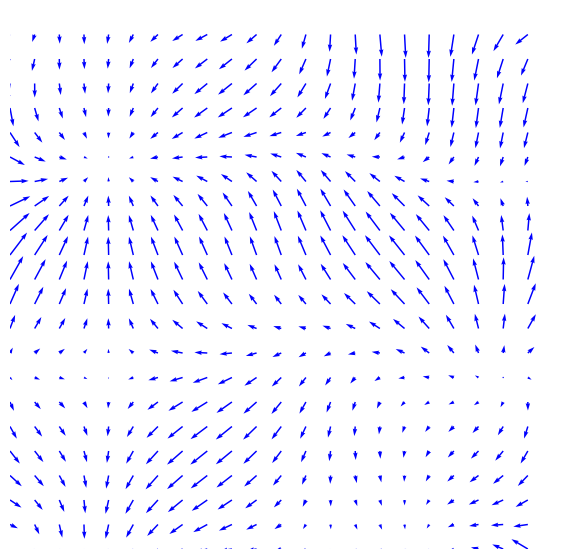

In [14]:
U = ProjI(V)
plt.figure(figsize=(7, 7))
myplot(U)

Display $W=U-V$ the irrotational component of $V$.


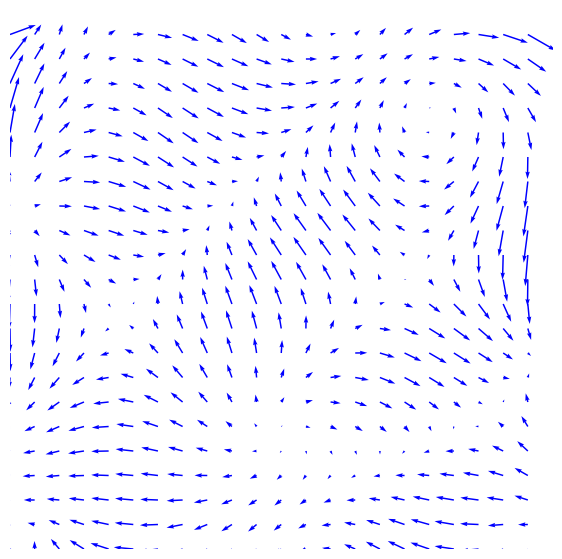

In [15]:
plt.figure(figsize=(7, 7))
myplot(V - U)

Note that the decomposition $V=U+W$ is called the Hoge decomposition of
the vector field.


Image Advection Along the Flow
------------------------------
A flow defines a warping operator that transport the content of an image
along the streaming of the flow.


We load an image $f$.


In [16]:
f = load_image("nt_toolbox/data/hibiscus.bmp", 2 * n)
f = f[np.ix_(np.arange(n - n // 2, n + n // 2), np.arange(n - n // 2, n + n // 2))]

Given some vector field $U$, the warping operator $f_1 = \Ww_U(f)$
along the flow is defined
$$ f_1(x) = f(x+U(x)) $$
i.e. it advects the values of $f$ by the vector field $U$ to obtain the values of $f_1$.


We define $U$ as a scaled normalized incompressible flow.


In [17]:
U = normalize(ProjI(V))

Helper function: enforce periodicity.


In [18]:
periodic = lambda P: np.concatenate(
    ((P[:, :, 0] % n)[:, :, np.newaxis], (P[:, :, 1] % n)[:, :, np.newaxis]), axis=2
)

Helper function: extend an image by 1 pixel to avoid boundary problems.


In [19]:
extend1 = lambda f: np.hstack((f, f[:, [0]]))
extend = lambda f: np.transpose(extend1(np.transpose(extend1(f))))

Helper function: bilinear interpolation on a grid.


In [20]:
from scipy import interpolate


def myinterp(P1, f1, Pi):
    return interpolate.griddata(P1, np.ravel(f1), (Pi[:, :, 1], Pi[:, :, 0]))

First we compute the initial and wraped grids.


In [21]:
Y, X = np.meshgrid(np.arange(0, n), np.arange(0, n))
P = np.concatenate((X[:, :, np.newaxis], Y[:, :, np.newaxis]), axis=2)
Y1, X1 = np.meshgrid(np.arange(0, n + 1), np.arange(0, n + 1))
P1 = np.concatenate((np.ravel(Y1)[:, np.newaxis], np.ravel(X1)[:, np.newaxis]), axis=1)

Defines the warping operator $\Ww_U$.


In [22]:
W = lambda f, U: myinterp(P1, extend(f), periodic(P - U))

Display a warped image $\Ww_{\rho U}(f)$ for some scaling $\rho$.


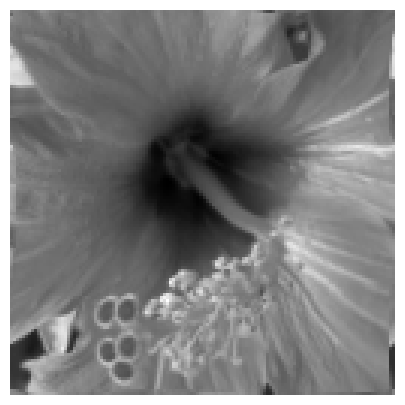

In [23]:
rho = 2
plt.figure(figsize=(5, 5))
imageplot(W(f, rho * U))

__Worked example 1__

Display $\Ww_{\rho U}(f)$ for various values of $\rho$.


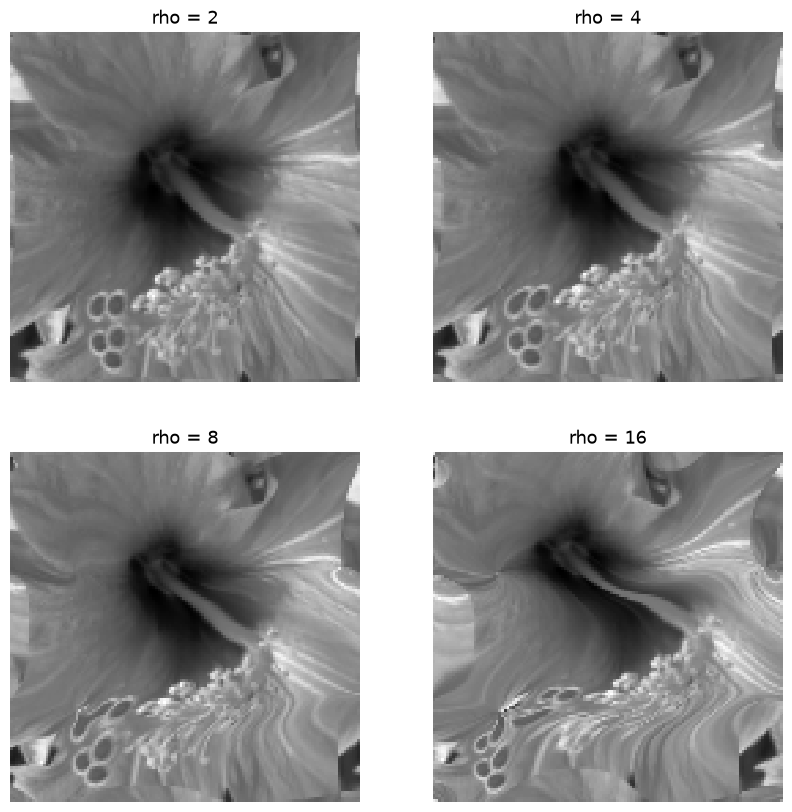

In [24]:
plt.figure(figsize=(10, 10))
rho_list = [2, 4, 8, 16]

for i in range(len(rho_list)):
    rho = rho_list[i]
    imageplot(W(f, rho * U), "rho = %i" % rho, [2, 2, i + 1])

__Worked example 2__

Define an iterative scheme via:
$$ f^{(\ell+1)} = \Ww_{\rho U}(f^{(\ell)}).  $$
Display the result $f^{(\ell)}$, which corresponds approximately to solving
an advection equation at time $t=\ell \rho$.


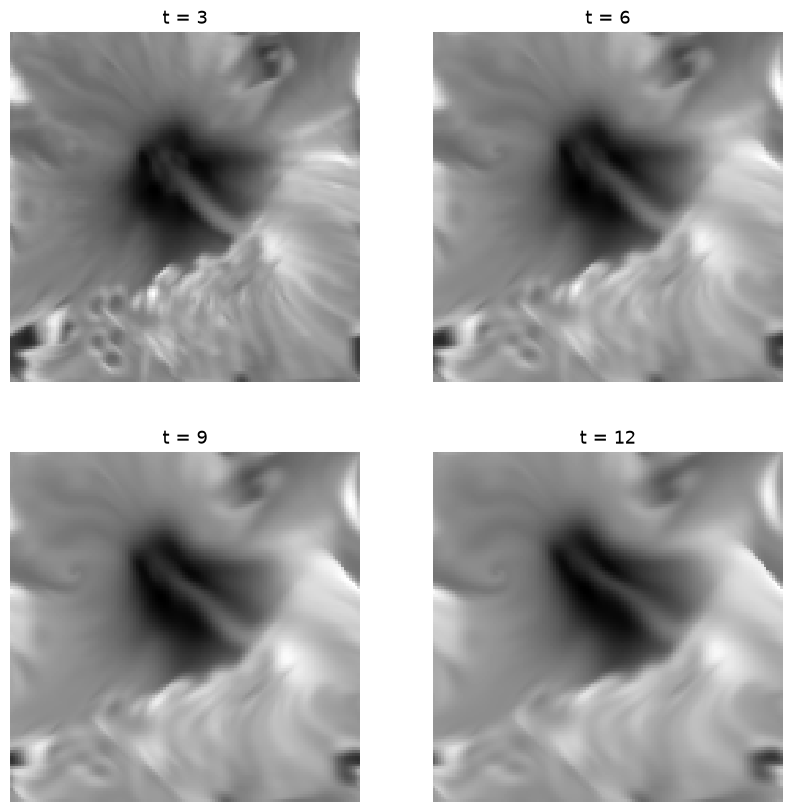

In [25]:
plt.figure(figsize=(10, 10))
rho = 0.25
niter = 12 * 4
k = 0
f1 = np.copy(f)
for i in range(1, niter + 1):
    f1 = W(f1, rho * U)
    if i % (niter // 4) == 0:
        k += 1
        imageplot(f1, "t = %i" % (i * rho), [2, 2, k])

Fluid Dynamics
--------------
Fluid dynamics solves the incompressible Navier-Stokes equations to
evolve in time the vector field.


We discribe here a simple algorithm introduced in:


J. Stam, _Stable Fluids,_
SIGGRAPH'99, 1999, p. 121-128.


It proposes a semi-implicit scheme for the resolution of the Navier
Stockes equations for the movement of incompressible fluids
$$
      \pd{V}{t} =
      \text{Proj}_{\Ii}\pa{
          -(V \cdot \nabla) V + \nu \Delta V + W
      }.
$$
Here $\nu \geq 0$ is the viscosity of the fluid,
$W$ is a source term, $\Delta$ is the Laplacian, and
$-(V \cdot \nabla) V$ is the
non-linear self-advection, where we have used the short-hand
notation $V \cdot \nabla$ for the derivative operator along a flow $V$:
$$ (V \cdot \nabla)U = ( V_1 \pd{U_1}{x_1} + V_2 \pd{U_1}{x_2},
      V_1 \pd{U_2}{x_1} + V_2 \pd{U_2}{x_2} ).$$


In order to visualize the flow, we also advect and diffuse along the flow
a density $g$ of particules, which is a scalar field. Once $V$ has
been computed, it follows a linear PDE
$$
      \pd{g}{t} =
          -(V \cdot \nabla) g + \mu \Delta g + h
$$
with some initial condition at time $t=0$, where $h$ is a source for the density.


In practice, we solve this PDE in parallel to the PDE for $V$.


In the following, we use $W=0$ and $h=0$ (no sources).


Set the viscosity $\nu$ for the velocity field.


In [26]:
nu = 1 / 10
mu = nu

Extend the warping operator $\Ww_U$ to work with vector fields as input.
This will apply $\Ww_U$ on each channel of the vector field (X and Y coordinates).


In [27]:
# Wt = lambda V, U: np.concatenate((W(V[:,:,0],U)[:,:,np.newaxis],W(V[:,:,1],U)[:,:,np.newaxis]),axis=2)
Wt = lambda V, U: np.dstack((W(V[:, :, 0], U), W(V[:, :, 1], U)))

We discretize the PDE's using some time step $\tau$.


In [28]:
tau = 0.03

The algorithm computes $V^{(\ell)}$ at iteration $\ell$
which is an approximation of the PDE solution at time $\ell \tau$.
It is computed itertatively as
$$
      \tilde V^{(\ell)} = \Ww_{\tau V^{(\ell)}}( V^{(\ell)} )
  \qandq
      V^{(\ell+1)} = \text{Proj}_{\Ii}\pa{ \tilde V^{(\ell)} + \tau\nu\Delta \tilde V^{(\ell)} + \tau W  }
$$


It computes in parallel the evolution of the density as
$$
      \tilde g^{(\ell)} = \Ww_{\tau V^{(\ell)}}( g^{(\ell)} )
  \qandq
      g^{(\ell+1)} = \tilde g^{(\ell)} + \tau\nu\Delta \tilde g^{(\ell)} + \tau h
$$



Set the initial field $V=V^{(0)}$ at time $t=0$.


In [29]:
U = ProjI(V)

Set the initial density $g=g^{(0)}$ at time $t=0$.


In [30]:
g = np.copy(f)

The first step is to advect the vector field $V$ and $g$ along the flow $V$ itself.
This corresponds to an implict discretization of the term
$-(V \cdot \nabla) V$.


In [31]:
g = W(g, tau * U)
U = Wt(U, tau * U)

We implement the Laplacian using finite difference.


The second step is to diffuse the vector field and the density.


In [32]:
U = U + tau * nu * DeltaV(U)
g = g + tau * mu * Delta(g)

The last step is to ensure incompressibility of $V$ by projecting on $\Ii$.


In [33]:
U = ProjI(U)

__Worked example 3__

Compute the fluid dynamic by iterating these steps.


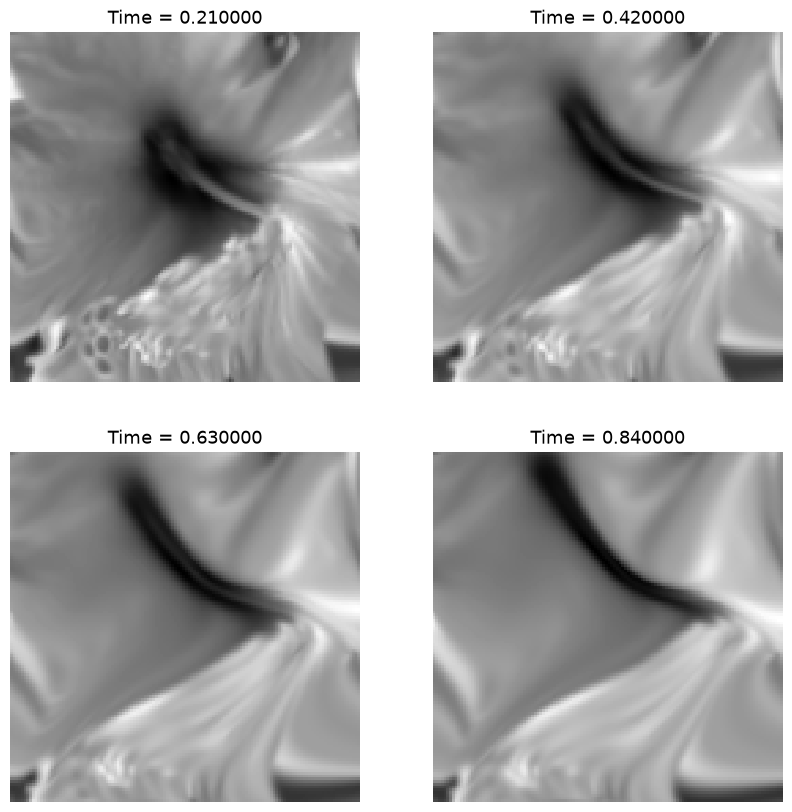

In [34]:
plt.figure(figsize=(10, 10))
U = ProjI(V)
g = np.copy(f)
k = 0

tau = 0.03
niter = 30

for i in range(1, niter + 1):
    # advect
    g = W(g, tau * V)
    U = Wt(U, tau * V)

    # Z = U
    # U[:,:,0] = W(Z[:,:,0],tau*Z)
    # U[:,:,1] = W(Z[:,:,1],tau*Z)

    # diffuse
    U = U + tau * nu * DeltaV(U)
    g = g + tau * mu * Delta(g)
    # project
    U = ProjI(U)
    # additional constraints

    # display
    if i % (niter // 4) == 0:
        k += 1
        imageplot(g, "Time = %f" % (i * tau), [2, 2, k])

## References and further reading

- Jos Stam. [Stable Fluids](https://doi.org/10.1145/311535.311548). 1999, SIGGRAPH, 121–128. Semi-Lagrangian advection and incompressible velocity projection.

- Robert Bridson. [Fluid Simulation for Computer Graphics](https://doi.org/10.1201/b18320). 2015, 2nd ed., CRC Press. Discretization, advection, pressure solves, and boundary conditions.

- Stanley Osher and James A. Sethian. [Fronts Propagating with Curvature-Dependent Speed: Algorithms Based on Hamilton–Jacobi Formulations](https://doi.org/10.1016/0021-9991(88)90002-2). 1988, Journal of Computational Physics 79(1), 12–49. Implicit front propagation using level-set functions.

- Pauli Virtanen et al.. [SciPy 1.0: Fundamental Algorithms for Scientific Computing in Python](https://doi.org/10.1038/s41592-019-0686-2). 2020, Nature Methods 17, 261–272. The numerical routines used for transforms, interpolation, and optimization.

- Gabriel Peyré. [Advanced Signal, Image and Surface Processing](https://www.numerical-tours.com/book/AdvancedSignalProcessing.pdf). 2010, course notes. A mathematical companion to the Numerical Tours.
